Предиктивная модель для прогноза стоимости акций российских компаний

In [110]:
import numpy as np # для работы с массивами и тензорами 
import pandas as pd # для работы с табллицами 
import matplotlib.pyplot as plt # визуализация 

import torch # построение и обучение модели нейронной сети  
import torch.nn as nn
import torch.optim as optim
 
from sklearn.preprocessing import StandardScaler # масштабирование и оценка модели
from sklearn.metrics import root_mean_squared_error 

from data_loader import get_moex_history # ticker  = ['SBER', 'YNDX'] для нормальных тикеров
from data_loader import get_moex_history_2_tickers # ticker  = [['YDEX'], ['YNDX']] для компаний, которые меняли тикер 




In [111]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

In [112]:
ticker  = [['YNDX'], ['YDEX']]
data_yndx = get_moex_history_2_tickers(ticker, "2022-03-30", "2026-02-01")
df = data_yndx['CLOSE']

<Axes: >

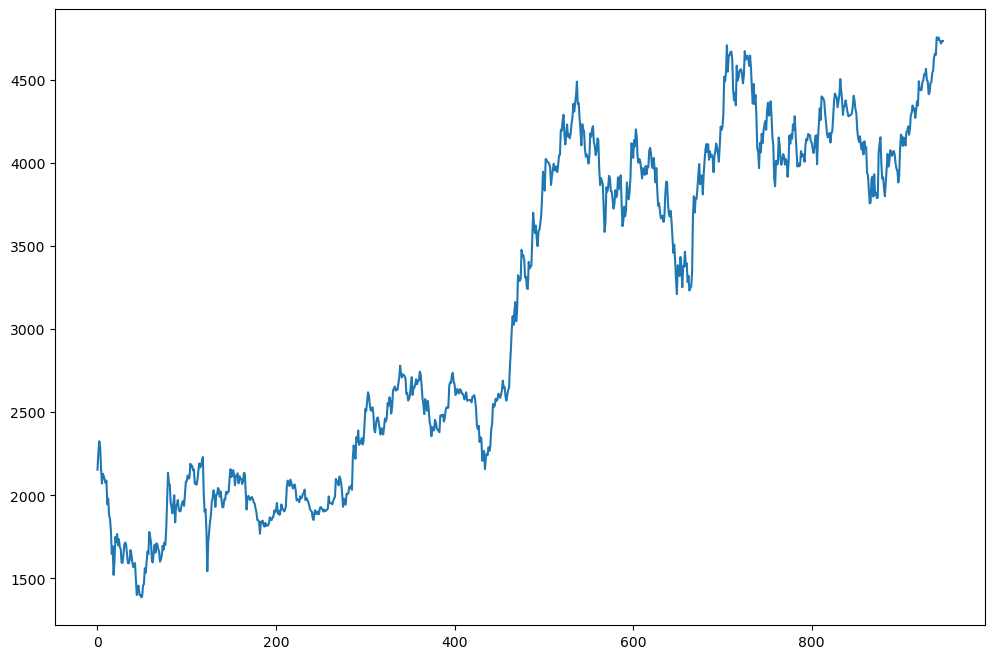

In [113]:
df.plot( y='CLOSE', figsize=(12, 8))

In [114]:
scaler = StandardScaler()
df = scaler.fit_transform(pd.DataFrame(df))

df = pd.DataFrame(df)


In [115]:
seq_len = 60
data =[]
for i in range (len(df) - seq_len):
    data.append(df[i:i+seq_len])
data = np.array(data)
train_size  =int(0.8 * len(data))


In [116]:
X_train = torch.from_numpy(data[:train_size, :-3, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -3, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-3, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -3, :]).type(torch.Tensor).to(device)

In [117]:
class PredictionModel(nn.Module):
	def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
		super(PredictionModel ,self).__init__()

		self.num_layers = num_layers
		self.hidden_dim = hidden_dim

		self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True) # dropout = 0.2
		self.fc = nn.Linear(hidden_dim, output_dim)
	
	def forward(self, x):
		if x.dim() == 2:
			x = x.unsqueeze(-1)  # добавляем seq_len

		h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
		c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)

		out, _ = self.lstm(x, (h0, c0))
		out = self.fc(out[:, -1])
		return out
         

In [118]:
model = PredictionModel(input_dim=1 , hidden_dim= 32 , num_layers=2 ,output_dim=1).to(device)

In [119]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [120]:
num_epochs = 200

for i in range(num_epochs):
	y_train_pred = model(X_train)

	loss = criterion(y_train_pred ,y_train)

	if i%25 == 0:
		print(i, loss)
	
	optimizer.zero_grad()
	loss.backward()
	optimizer.step()

0 tensor(0.8720, grad_fn=<MseLossBackward0>)
25 tensor(0.0395, grad_fn=<MseLossBackward0>)
50 tensor(0.0112, grad_fn=<MseLossBackward0>)
75 tensor(0.0088, grad_fn=<MseLossBackward0>)
100 tensor(0.0077, grad_fn=<MseLossBackward0>)
125 tensor(0.0069, grad_fn=<MseLossBackward0>)
150 tensor(0.0063, grad_fn=<MseLossBackward0>)
175 tensor(0.0058, grad_fn=<MseLossBackward0>)


In [121]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [122]:
train_rmse = root_mean_squared_error(y_train[:,0], y_train_pred[:,0])
test_rmse = root_mean_squared_error(y_test[:,0], y_test_pred[:,0])
print(f"{train_rmse:.3f}", f"{test_rmse:.3f}")

74.750 74.339


<function matplotlib.pyplot.show(close=None, block=None)>

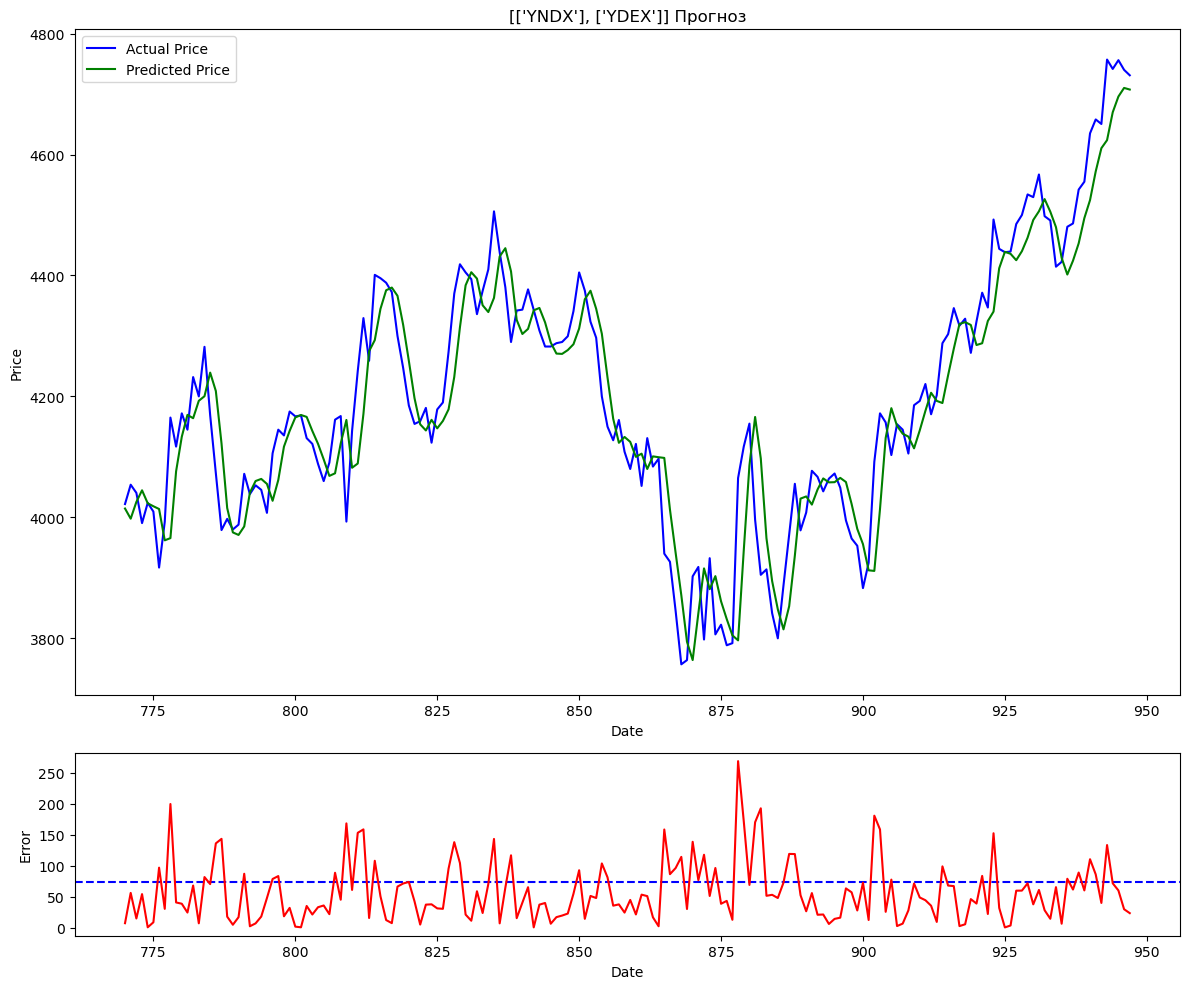

In [123]:
fig = plt.figure(figsize=(12,10))

gs = fig.add_gridspec(4,1)

ax1 = fig.add_subplot(gs[:3,0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue' , label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green' , label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Прогноз")
plt.xlabel('Date')
plt.ylabel('Price')


ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred),'r', label = 'Prediction Error' )
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show
